# CREDISCORE-BSIC : Pipeline de scoring credit

**Memoire** : Modelisation predictive du risque de defaut de paiement de credit dans le secteur bancaire tchadien, apport du Machine Learning au scoring credit, cas de la BSIC Tchad.

Ce notebook realise l'ensemble du travail technique : exploration des donnees, preparation, entrainement et comparaison de trois modeles (regression logistique, Random Forest, Gradient Boosting), score metier, explicabilite (SHAP) et sauvegarde du meilleur modele.

**Pour l'executer** : placer le fichier `application_train.csv` dans le meme dossier que ce notebook, puis executer les cellules dans l'ordre.

## 1. Importation des bibliotheques

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import joblib

# Graine aleatoire fixee pour la reproductibilite
GRAINE = 42
np.random.seed(GRAINE)

## 2. Chargement des donnees et selection des variables BSIC

On charge le jeu de donnees complet, puis on ne garde que les variables correspondant aux informations de la fiche de pret de la BSIC (profil du demandeur, credit, revenus, et les scores externes qui jouent le role de centrale des risques).

In [6]:
# Chargement du fichier complet
df_full = pd.read_csv("application_train.csv")

# Variables retenues (correspondant a la fiche de pret BSIC)
variables_bsic = [
    # Profil du demandeur
    "DAYS_BIRTH", "CODE_GENDER", "NAME_FAMILY_STATUS", "CNT_CHILDREN",
    "CNT_FAM_MEMBERS", "NAME_EDUCATION_TYPE", "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE", "NAME_INCOME_TYPE", "DAYS_EMPLOYED",
    # Credit et revenus
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "NAME_CONTRACT_TYPE",
    # Proxy de centrale des risques
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    # Cible : 1 = defaut, 0 = sain
    "TARGET",
]
df = df_full[variables_bsic].copy()
print("Dimensions du jeu de travail :", df.shape)
df.head()

Dimensions du jeu de travail : (307511, 19)


,DAYS_BIRTH,CODE_GENDER,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_EDUCATION_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,NAME_INCOME_TYPE,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_CONTRACT_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,TARGET
0,-9461,M,Single / not married,0,1.0,Secondary / secondary special,Laborers,Business Entity Type 3,Working,-637,202500.0,406597.5,24700.5,351000.0,Cash loans,0.083037,0.262949,0.139376,1
1,-16765,F,Married,0,2.0,Higher education,Core staff,School,State servant,-1188,270000.0,1293502.5,35698.5,1129500.0,Cash loans,0.311267,0.622246,NaN,0
2,-19046,M,Single / not married,0,1.0,Secondary / secondary special,Laborers,Government,Working,-225,67500.0,135000.0,6750.0,135000.0,Revolving loans,NaN,0.555912,0.729567,0
3,-19005,F,Civil marriage,0,2.0,Secondary / secondary special,Laborers,Business Entity Type 3,Working,-3039,135000.0,312682.5,29686.5,297000.0,Cash loans,NaN,0.650442,NaN,0
4,-19932,M,Single / not married,0,1.0,Secondary / secondary special,Core staff,Religion,Working,-3038,121500.0,513000.0,21865.5,513000.0,Cash loans,NaN,0.322738,NaN,0


## 3. Nettoyage des donnees

Quatre corrections :
- **DAYS_EMPLOYED** contient la valeur aberrante 365243 (1000 ans) pour les retraites : on garde l'information dans une indicatrice, puis on la met a NaN.
- On convertit l'age et l'anciennete d'emploi en **annees** (stockes en jours negatifs).
- On corrige le **genre inconnu** (quelques valeurs "XNA").
- On plafonne les **revenus extremes** (capping au 99,9e centile).

In [7]:
# Indicatrice retraite / sans emploi + mise a NaN de la valeur aberrante
df["EMPLOI_ANORMAL"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

# Conversion en annees
df["AGE_ANNEES"] = (-df["DAYS_BIRTH"] / 365).round(1)
df["ANCIENNETE_EMPLOI_ANNEES"] = (-df["DAYS_EMPLOYED"] / 365).round(1)
df = df.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"])

# Correction du genre inconnu
df["CODE_GENDER"] = df["CODE_GENDER"].replace("XNA", "F")

# Plafonnement des revenus extremes
plafond = df["AMT_INCOME_TOTAL"].quantile(0.999)
df["AMT_INCOME_TOTAL"] = df["AMT_INCOME_TOTAL"].clip(upper=plafond)

print("Nettoyage termine. Dimensions :", df.shape)
df.head()

Nettoyage termine. Dimensions : (307511, 20)


,CODE_GENDER,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_EDUCATION_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,NAME_INCOME_TYPE,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_CONTRACT_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,TARGET,EMPLOI_ANORMAL,AGE_ANNEES,ANCIENNETE_EMPLOI_ANNEES
0,M,Single / not married,0,1.0,Secondary / secondary special,Laborers,Business Entity Type 3,Working,202500.0,406597.5,24700.5,351000.0,Cash loans,0.083037,0.262949,0.139376,1,0,25.9,1.7
1,F,Married,0,2.0,Higher education,Core staff,School,State servant,270000.0,1293502.5,35698.5,1129500.0,Cash loans,0.311267,0.622246,NaN,0,0,45.9,3.3
2,M,Single / not married,0,1.0,Secondary / secondary special,Laborers,Government,Working,67500.0,135000.0,6750.0,135000.0,Revolving loans,NaN,0.555912,0.729567,0,0,52.2,0.6
3,F,Civil marriage,0,2.0,Secondary / secondary special,Laborers,Business Entity Type 3,Working,135000.0,312682.5,29686.5,297000.0,Cash loans,NaN,0.650442,NaN,0,0,52.1,8.3
4,M,Single / not married,0,1.0,Secondary / secondary special,Core staff,Religion,Working,121500.0,513000.0,21865.5,513000.0,Cash loans,NaN,0.322738,NaN,0,0,54.6,8.3


## 4. Analyse exploratoire

On regarde la taille du jeu, la repartition de la cible (defaut), les valeurs manquantes et quelques statistiques.

In [8]:
# Repartition de la cible
print("=== Repartition de la cible (defaut de paiement) ===")
vc = df["TARGET"].value_counts()
print("Sains (0)     : {} ({:.2f}%)".format(vc[0], 100*vc[0]/len(df)))
print("Defauts (1)   : {} ({:.2f}%)".format(vc[1], 100*vc[1]/len(df)))
print()

# Valeurs manquantes
print("=== Valeurs manquantes (%) ===")
miss = (df.isnull().mean()*100).round(1)
print(miss[miss > 0].sort_values(ascending=False).to_string())

=== Repartition de la cible (defaut de paiement) ===
Sains (0)     : 282686 (91.93%)
Defauts (1)   : 24825 (8.07%)

=== Valeurs manquantes (%) ===
EXT_SOURCE_1                56.4
OCCUPATION_TYPE             31.3
EXT_SOURCE_3                19.8
ANCIENNETE_EMPLOI_ANNEES    18.0
EXT_SOURCE_2                 0.2
AMT_GOODS_PRICE              0.1


In [9]:
# Statistiques des principales variables numeriques
vars_num = ["AGE_ANNEES", "ANCIENNETE_EMPLOI_ANNEES", "AMT_INCOME_TOTAL",
            "AMT_CREDIT", "AMT_ANNUITY", "EXT_SOURCE_2"]
df[vars_num].describe().round(1)

,AGE_ANNEES,ANCIENNETE_EMPLOI_ANNEES,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,EXT_SOURCE_2
count,307511.0,252137.0,307511.0,307511.0,307499.0,306851.0
mean,43.9,6.5,167771.4,599026.0,27108.6,0.5
std,12.0,6.4,91928.9,402490.8,14493.7,0.2
min,20.5,0.0,25650.0,45000.0,1615.5,0.0
25%,34.0,2.1,112500.0,270000.0,16524.0,0.4
50%,43.2,4.5,147150.0,513531.0,24903.0,0.6
75%,53.9,8.7,202500.0,808650.0,34596.0,0.7
max,69.1,49.1,900000.0,4050000.0,258025.5,0.9


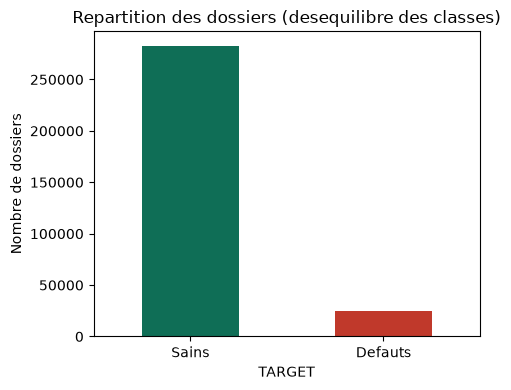

In [10]:
# Graphique : repartition de la cible
plt.figure(figsize=(5,4))
df["TARGET"].value_counts().plot(kind="bar", color=["#0F6E56", "#C0392B"])
plt.xticks([0,1], ["Sains", "Defauts"], rotation=0)
plt.title("Repartition des dossiers (desequilibre des classes)")
plt.ylabel("Nombre de dossiers")
plt.tight_layout()
plt.show()

## 5. Analyse de correlation

On regarde quelles variables numeriques sont liees au defaut, et lesquelles sont redondantes entre elles.

In [11]:
# Correlation des variables numeriques avec la cible
num = df.select_dtypes(include=[np.number])
corr_cible = num.corr()["TARGET"].drop("TARGET").sort_values()
print("=== Correlation de chaque variable avec le DEFAUT ===")
print(corr_cible.round(3).to_string())

=== Correlation de chaque variable avec le DEFAUT ===
EXT_SOURCE_3               -0.179
EXT_SOURCE_2               -0.160
EXT_SOURCE_1               -0.155
AGE_ANNEES                 -0.078
ANCIENNETE_EMPLOI_ANNEES   -0.075
EMPLOI_ANORMAL             -0.046
AMT_GOODS_PRICE            -0.040
AMT_CREDIT                 -0.030
AMT_INCOME_TOTAL           -0.023
AMT_ANNUITY                -0.013
CNT_FAM_MEMBERS             0.009
CNT_CHILDREN                0.019


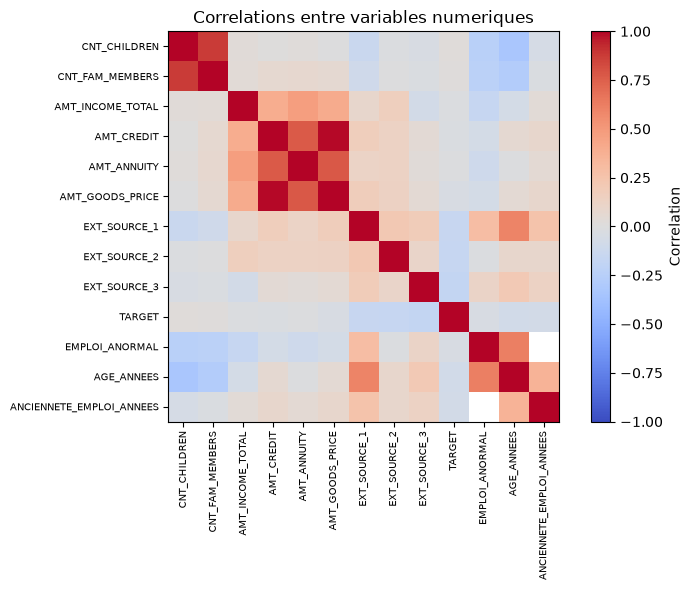

In [12]:
# Carte de chaleur des correlations
import numpy as np
plt.figure(figsize=(8,6))
c = num.corr()
plt.imshow(c, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(c.columns)), c.columns, rotation=90, fontsize=7)
plt.yticks(range(len(c.columns)), c.columns, fontsize=7)
plt.title("Correlations entre variables numeriques")
plt.tight_layout()
plt.show()

### Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence plusieurs enseignements.

**Des groupes de variables redondantes.** Certaines variables sont fortement
corrélées entre elles (zones rouge foncé). C'est le cas des montants
(`AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`), qui évoluent ensemble :
plus le bien est cher, plus le crédit et l'échéance sont élevés. De même,
`CNT_CHILDREN` et `CNT_FAM_MEMBERS` sont presque identiques. Ces redondances
indiquent que ces variables portent une information proche.

**Un lien faible mais lisible avec le défaut.** Face à la variable cible
(`TARGET`), les corrélations sont faibles mais interprétables. Les trois
scores externes de risque (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`)
présentent une corrélation négative : plus le score est élevé, plus le risque
de défaut diminue. L'âge et l'ancienneté d'emploi vont dans le même sens
protecteur.

**Aucune variable ne suffit à elle seule.** Toutes les corrélations avec la
cible restent faibles. Le défaut de paiement ne s'explique donc pas par une
seule variable, mais par la combinaison de plusieurs. Ce constat justifie le
recours à des modèles capables de capter ces interactions complexes, comme le
gradient boosting, plutôt qu'à une règle sur une variable isolée.

**Remarque technique.** Les cases blanches entre `EMPLOI_ANORMAL` et
`ANCIENNETE_EMPLOI_ANNEES` traduisent une corrélation non calculable : les
personnes concernées par `EMPLOI_ANORMAL` (retraités et sans-emploi) sont
précisément celles dont l'ancienneté est manquante. Les deux variables ne se
recouvrent jamais.

## 6. Preparation des donnees (train/test + pipeline)

On separe les donnees en entrainement (80%) et test (20%), de facon stratifiee pour conserver le meme taux de defaut. Puis on construit le preparateur (imputation des valeurs manquantes, mise a l'echelle, encodage des variables categorielles). **La preparation est apprise sur le train uniquement**, ce qui evite toute fuite de donnees.

In [13]:
# Separation cible / variables explicatives
y = df["TARGET"]
X = df.drop(columns=["TARGET"])

# Separation train / test (stratifiee)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=GRAINE, stratify=y)

print("Train :", X_train.shape[0], "dossiers | Test :", X_test.shape[0], "dossiers")
print("Taux de defaut train : {:.2f}% | test : {:.2f}%".format(
    100*y_train.mean(), 100*y_test.mean()))

# Colonnes numeriques et categorielles
colonnes_num = X_train.select_dtypes(include=[np.number]).columns.tolist()
colonnes_cat = [c for c in X_train.columns if c not in colonnes_num]

# Preparateur : numeriques (imputation mediane + standardisation),
# categorielles (imputation mode + encodage one-hot)
preparateur = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())]), colonnes_num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), colonnes_cat),
])
print("Preparateur construit.")

Train : 246008 dossiers | Test : 61503 dossiers
Taux de defaut train : 8.07% | test : 8.07%
Preparateur construit.


## 7. Definition des trois modeles

- **Regression logistique** : le modele de reference (baseline), simple et interpretable.
- **Random Forest** : modele d'ensemble par bagging.
- **Gradient Boosting (LightGBM)** : modele d'ensemble par boosting.

Le desequilibre des classes est traite par **ponderation** (`class_weight="balanced"`), qui donne de meilleurs resultats que SMOTE sur ces donnees.

In [14]:
modeles = {
    "Regression logistique": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=GRAINE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=50,
        class_weight="balanced", n_jobs=-1, random_state=GRAINE),
    "Gradient Boosting": LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=20,
        class_weight="balanced", n_jobs=-1, random_state=GRAINE, verbose=-1),
}
print("Trois modeles definis.")

Trois modeles definis.


## 8. Entrainement et comparaison des modeles

On entraine chaque modele, on evalue son AUC en validation croisee (sur le train) et sur le jeu de test. L'AUC est la metrique principale de comparaison.

In [15]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=GRAINE)
resultats = {}

for nom, clf in modeles.items():
    pipe = Pipeline([("prep", preparateur), ("clf", clf)])
    # AUC en validation croisee
    auc_cv = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1).mean()
    # Entrainement final + evaluation sur le test
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc_test = roc_auc_score(y_test, proba)
    resultats[nom] = {"pipeline": pipe, "proba": proba,
                      "auc_cv": auc_cv, "auc_test": auc_test}
    print("{:<24} AUC(cv) = {:.4f} | AUC(test) = {:.4f}".format(
        nom, auc_cv, auc_test))

Regression logistique    AUC(cv) = 0.7387 | AUC(test) = 0.7403
Random Forest            AUC(cv) = 0.7343 | AUC(test) = 0.7372
Gradient Boosting        AUC(cv) = 0.7504 | AUC(test) = 0.7527


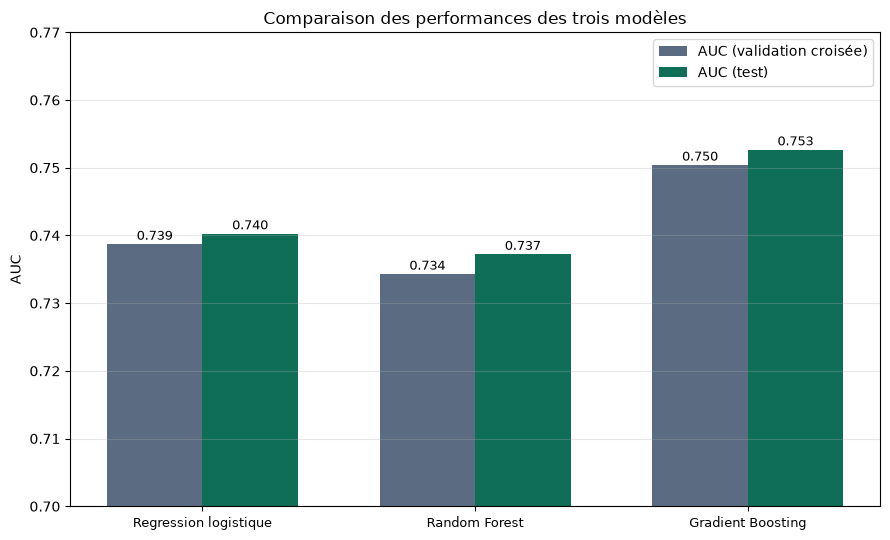

In [23]:
# Histogramme comparatif des AUC des trois modeles
noms = list(resultats.keys())
auc_cv = [resultats[n]["auc_cv"] for n in noms]
auc_test = [resultats[n]["auc_test"] for n in noms]

x = np.arange(len(noms))
largeur = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
barres1 = ax.bar(x - largeur/2, auc_cv, largeur, label="AUC (validation croisée)", color="#5A6B82")
barres2 = ax.bar(x + largeur/2, auc_test, largeur, label="AUC (test)", color="#0F6E56")

# Afficher la valeur au-dessus de chaque barre
for barres in [barres1, barres2]:
    for b in barres:
        h = b.get_height()
        ax.annotate("{:.3f}".format(h), xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)

ax.set_ylabel("AUC")
ax.set_title("Comparaison des performances des trois modèles")
ax.set_xticks(x)
ax.set_xticklabels(noms, fontsize=9)
ax.set_ylim(0.70, 0.77)   # zoom sur la zone utile pour bien voir les écarts
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation de la comparaison des modèles

L'histogramme compare les performances des trois modèles, mesurées par l'AUC,
à la fois en validation croisée et sur le jeu de test.

Le **Gradient Boosting** obtient la meilleure performance, avec une AUC de
0,753 sur le test, devant le Random Forest (0,737) et la régression logistique
(0,740). Ce classement confirme notre hypothèse : les modèles d'ensemble, et
en particulier le gradient boosting, offrent un meilleur pouvoir de
discrimination que la régression logistique prise comme référence.

Pour chaque modèle, l'AUC en validation croisée et l'AUC sur le test sont très
proches, ce qui indique que les performances sont stables et que les modèles
généralisent bien.

**Remarque de lecture.** L'axe vertical débute à 0,70 afin de rendre visibles
les écarts entre les modèles, qui restent modestes. La supériorité du gradient
boosting est réelle et constante, mais l'écart avec les autres modèles doit
être relativisé : il se joue à quelques millièmes d'AUC, ce qui est cohérent
avec la littérature sur le scoring de crédit.

## 9. Controle du surapprentissage (overfitting)

Avant d'aller plus loin, on verifie que les modeles ne "delirent" pas, c'est-a-dire qu'ils ne se contentent pas de memoriser les donnees d'entrainement. Pour cela, on compare l'AUC sur le train et sur le test : si l'ecart est faible, le modele generalise bien. Un ecart important revelerait du surapprentissage.

In [16]:
print("Controle du surapprentissage : AUC train vs AUC test")
print("="*60)
print("{:<24} {:>10} {:>10} {:>8}".format("Modele","AUC train","AUC test","Ecart"))
print("-"*60)
for nom, r in resultats.items():
    proba_train = r["pipeline"].predict_proba(X_train)[:, 1]
    auc_train = roc_auc_score(y_train, proba_train)
    ecart = auc_train - r["auc_test"]
    r["auc_train"] = auc_train
    r["ecart"] = ecart
    print("{:<24} {:>10.4f} {:>10.4f} {:>8.4f}".format(
        nom, auc_train, r["auc_test"], ecart))
print()
print("Interpretation : un ecart faible (< 0.05) indique que le modele")
print("generalise bien. Un ecart eleve signale un surapprentissage.")

Controle du surapprentissage : AUC train vs AUC test
Modele                    AUC train   AUC test    Ecart
------------------------------------------------------------
Regression logistique        0.7405     0.7403   0.0002
Random Forest                0.7599     0.7372   0.0226
Gradient Boosting            0.7718     0.7527   0.0192

Interpretation : un ecart faible (< 0.05) indique que le modele
generalise bien. Un ecart eleve signale un surapprentissage.


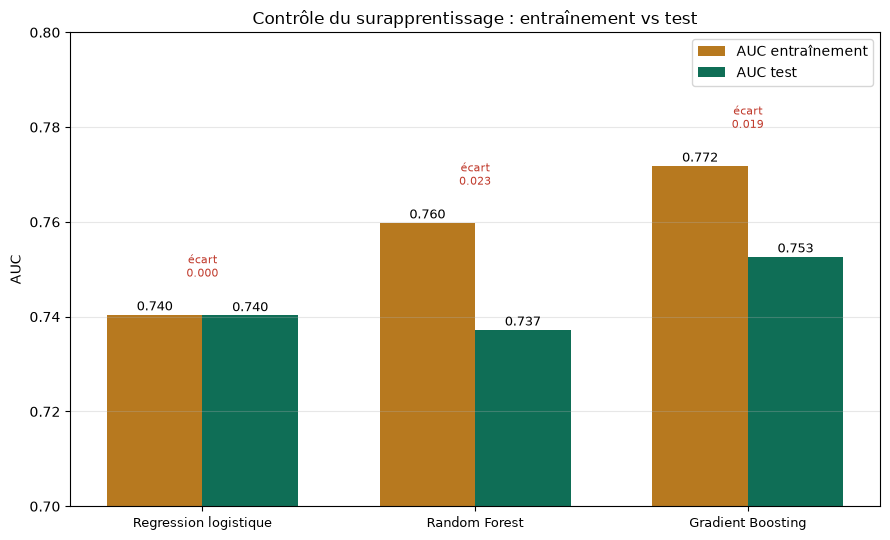

In [24]:
# Histogramme du controle du surapprentissage (AUC train vs test)
noms = list(resultats.keys())
auc_train = [resultats[n]["auc_train"] for n in noms]
auc_test = [resultats[n]["auc_test"] for n in noms]

x = np.arange(len(noms))
largeur = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - largeur/2, auc_train, largeur, label="AUC entraînement", color="#B7791F")
b2 = ax.bar(x + largeur/2, auc_test, largeur, label="AUC test", color="#0F6E56")

# Valeur au-dessus de chaque barre
for barres in [b1, b2]:
    for b in barres:
        h = b.get_height()
        ax.annotate("{:.3f}".format(h), xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)

# Afficher l'ecart au-dessus de chaque paire
for i, n in enumerate(noms):
    ecart = resultats[n]["auc_train"] - resultats[n]["auc_test"]
    ax.annotate("écart\n{:.3f}".format(ecart), xy=(i, max(auc_train[i], auc_test[i]) + 0.008),
                ha="center", fontsize=8, color="#C0392B")

ax.set_ylabel("AUC")
ax.set_title("Contrôle du surapprentissage : entraînement vs test")
ax.set_xticks(x)
ax.set_xticklabels(noms, fontsize=9)
ax.set_ylim(0.70, 0.80)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation du contrôle du surapprentissage

Ce graphique compare, pour chaque modèle, la performance sur les données
d'entraînement et sur les données de test. L'écart entre les deux mesure le
surapprentissage : si un modèle est bien meilleur sur l'entraînement que sur
le test, c'est qu'il a mémorisé les données au lieu d'apprendre des règles
générales.

Les trois modèles présentent un écart faible, tous très inférieurs au seuil
d'alerte de 0,05 :

- La **régression logistique** a un écart quasi nul (0,0002) : modèle simple,
  il ne surapprend pas, mais reste le moins performant.
- Le **Random Forest** présente un écart maîtrisé (0,023), obtenu après avoir
  limité sa profondeur et la taille de ses feuilles pour éviter qu'il ne
  mémorise les données.
- Le **Gradient Boosting** affiche un écart modéré (0,019) tout en conservant
  la meilleure performance : il est à la fois le plus précis et bien maîtrisé.

Ces résultats montrent que nos modèles généralisent correctement : leurs
bonnes performances ne sont pas dues à une mémorisation des données
d'entraînement, mais à une réelle capacité à prédire le défaut sur des
dossiers qu'ils n'ont jamais vus.

## 10. Score metier

Un faux negatif (defaut accorde par erreur) coute plus cher qu'un faux positif (bon client refuse). On retient un ratio de **5 pour 1**. On cherche, pour chaque modele, le seuil de decision qui minimise le cout total.

In [17]:
COUT_FN = 5  # cout d'un faux negatif
COUT_FP = 1  # cout d'un faux positif

def cout_metier(y_vrai, proba, seuil):
    pred = (proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_vrai, pred).ravel()
    return COUT_FN*fn + COUT_FP*fp

print("=== Score metier (ratio 5:1) ===")
seuils = np.arange(0.05, 0.95, 0.05)
for nom, r in resultats.items():
    couts = [cout_metier(y_test, r["proba"], s) for s in seuils]
    i = int(np.argmin(couts))
    r["seuil"] = round(float(seuils[i]), 2)
    r["cout"] = int(couts[i])
    print("{:<24} seuil optimal = {:.2f} | cout minimal = {}".format(
        nom, seuils[i], couts[i]))

=== Score metier (ratio 5:1) ===
Regression logistique    seuil optimal = 0.70 | cout minimal = 21446
Random Forest            seuil optimal = 0.60 | cout minimal = 21997
Gradient Boosting        seuil optimal = 0.70 | cout minimal = 20868


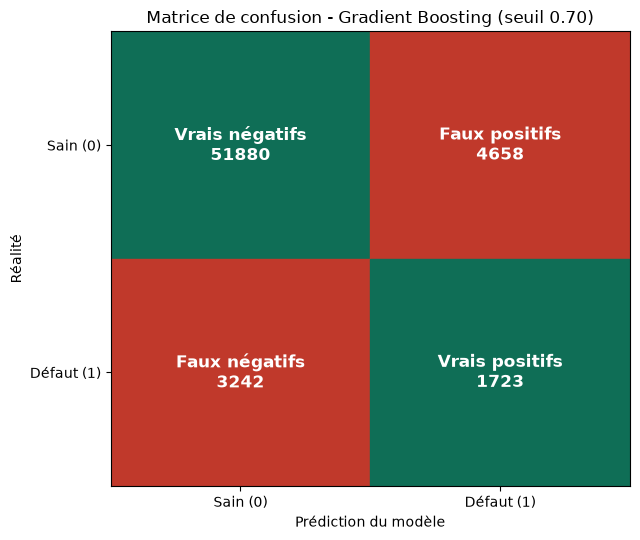

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix

proba_best = resultats[meilleur_nom]["proba"]
seuil_best = resultats[meilleur_nom]["seuil"]
pred_best = (proba_best >= seuil_best).astype(int)
cm = confusion_matrix(y_test, pred_best)
tn, fp, fn, tp = cm.ravel()

# Couleurs : vert pour les bonnes decisions (diagonale), rouge pour les erreurs
couleurs_fond = np.array([["#0F6E56", "#C0392B"],
                          ["#C0392B", "#0F6E56"]])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, color=couleurs_fond[i, j]))

noms_cases = [["Vrais négatifs", "Faux positifs"], ["Faux négatifs", "Vrais positifs"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, "{}\n{}".format(noms_cases[i][j], cm[i, j]),
                ha="center", va="center", color="white", fontsize=12, fontweight="bold")

ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Sain (0)", "Défaut (1)"])
ax.set_yticklabels(["Sain (0)", "Défaut (1)"])
ax.set_xlabel("Prédiction du modèle")
ax.set_ylabel("Réalité")
ax.set_title("Matrice de confusion - {} (seuil {:.2f})".format(meilleur_nom, seuil_best))
plt.tight_layout()
plt.show()

### Interprétation de la matrice de confusion

La matrice de confusion détaille les décisions du modèle retenu (Gradient
Boosting) sur le jeu de test, au seuil optimal de 0,70 qui minimise le coût
métier. Elle croise la réalité (le client a-t-il fait défaut ?) avec la
prédiction du modèle.

Quatre situations apparaissent :

- Les **vrais négatifs** : les bons clients correctement acceptés. C'est le
  cas le plus fréquent, et c'est souhaitable.
- Les **vrais positifs** : les défauts correctement détectés. Ce sont les
  crédits risqués que le modèle a su repérer.
- Les **faux positifs** : les bons clients refusés à tort. Ils représentent un
  manque à gagner pour la banque (marge perdue), mais pas une perte directe.
- Les **faux négatifs** : les défauts acceptés à tort. Ce sont les plus
  coûteux, car ils entraînent une perte réelle de capital. C'est pourquoi
  notre score métier leur attribue un poids cinq fois supérieur.

Le seuil de décision a été choisi pour minimiser le coût métier total, calculé
comme cinq fois le nombre de faux négatifs plus le nombre de faux positifs. Ce
réglage traduit la priorité d'une banque : mieux vaut refuser quelques bons
clients que d'accorder un crédit à un emprunteur qui fera défaut.

## 11. Selection du meilleur modele

On retient le modele avec la meilleure AUC de test. C'est une comparaison systematique : a chaque reentrainement, le meilleur modele du moment est selectionne.

In [18]:
meilleur_nom = max(resultats, key=lambda n: resultats[n]["auc_test"])
print("Meilleur modele :", meilleur_nom)
print("AUC(test) = {:.4f}".format(resultats[meilleur_nom]["auc_test"]))

Meilleur modele : Gradient Boosting
AUC(test) = 0.7527


## 12. Courbes ROC des trois modeles

Plus une courbe monte vite vers le coin haut-gauche, meilleur est le modele. La diagonale represente le hasard.

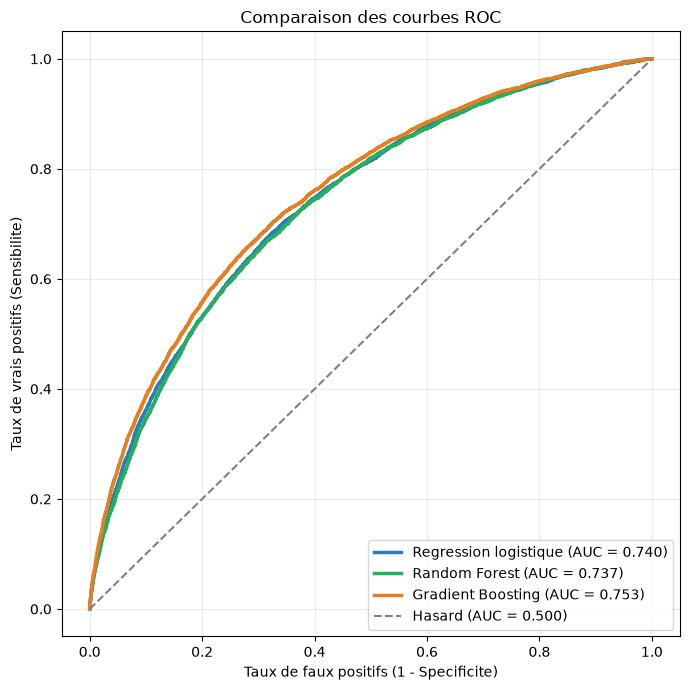

In [19]:
plt.figure(figsize=(7,7))
couleurs = {"Regression logistique": "#2980B9", "Random Forest": "#27AE60",
            "Gradient Boosting": "#E67E22"}
for nom, r in resultats.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    plt.plot(fpr, tpr, linewidth=2.5, color=couleurs[nom],
             label="{} (AUC = {:.3f})".format(nom, r["auc_test"]))
plt.plot([0,1], [0,1], "--", color="gray", label="Hasard (AUC = 0.500)")
plt.xlabel("Taux de faux positifs (1 - Specificite)")
plt.ylabel("Taux de vrais positifs (Sensibilite)")
plt.title("Comparaison des courbes ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 13. Explicabilite avec SHAP

On analyse les variables les plus determinantes du meilleur modele (le Gradient Boosting). Cette etape est essentielle : elle rend les decisions du modele explicables, condition d'acceptation par le regulateur (COBAC).

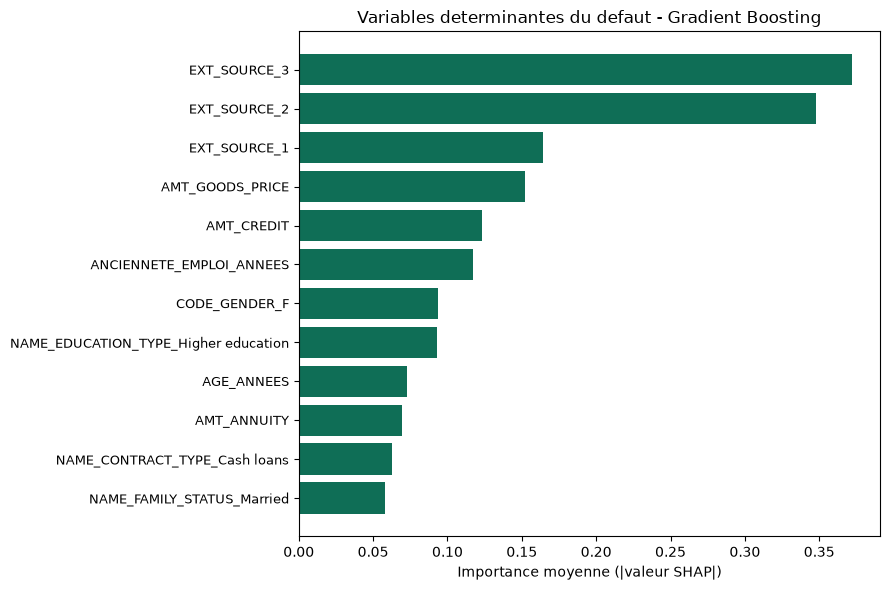

In [20]:
import shap

# On recupere le modele entraine et on prepare les donnees de test
pipe_best = resultats[meilleur_nom]["pipeline"]
X_test_prep = preparateur.transform(X_test)
noms_features = preparateur.get_feature_names_out()

# Le classifieur seul (dernier element du pipeline)
clf_best = pipe_best.named_steps["clf"]

# Calcul des valeurs SHAP sur un echantillon (pour la rapidite)
ech = X_test_prep[:2000]
explainer = shap.TreeExplainer(clf_best)
shap_values = explainer.shap_values(ech)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Importance globale
importance = np.abs(shap_values).mean(axis=0)
ordre = np.argsort(importance)[::-1][:12]
noms_courts = [noms_features[i].replace("num__","").replace("cat__","") for i in ordre]

plt.figure(figsize=(9,6))
plt.barh(range(len(ordre))[::-1], importance[ordre], color="#0F6E56")
plt.yticks(range(len(ordre))[::-1], noms_courts, fontsize=9)
plt.xlabel("Importance moyenne (|valeur SHAP|)")
plt.title("Variables determinantes du defaut - " + meilleur_nom)
plt.tight_layout()
plt.show()

### Interprétation de l'importance des variables (SHAP)

Ce graphique classe les variables selon leur importance dans les prédictions
du modèle, mesurée par la méthode SHAP. Plus la barre est longue, plus la
variable pèse dans la décision.

Les trois **scores externes de risque** (`EXT_SOURCE_3`, `EXT_SOURCE_2`,
`EXT_SOURCE_1`) dominent nettement le classement. Ils jouent, dans notre
étude, le rôle de la centrale des risques : ils résument les antécédents de
crédit du demandeur. Le modèle confirme donc que l'information sur le passé de
crédit est le facteur le plus déterminant pour prédire le défaut, ce qui
rejoint la pratique de la BSIC, qui consulte le rapport de la centrale des
risques lors de l'instruction d'un dossier.

Viennent ensuite les **variables financières** : le prix du bien financé
(`AMT_GOODS_PRICE`), le montant du crédit (`AMT_CREDIT`) et le montant de
l'échéance (`AMT_ANNUITY`). Ce sont les éléments qu'un banquier examine
naturellement, et ils figurent sur la fiche de prêt de la BSIC.

Enfin, des variables de **stabilité personnelle** apparaissent :
l'ancienneté d'emploi, l'âge, le niveau d'éducation et la situation
matrimoniale. Elles traduisent la solidité du profil du demandeur.

Ce classement montre que le modèle ne fonctionne pas comme une boîte noire
arbitraire : il s'appuie sur des critères que la banque reconnaît et peut
justifier, ce qui répond à l'exigence d'explicabilité posée par le régulateur
(COBAC).

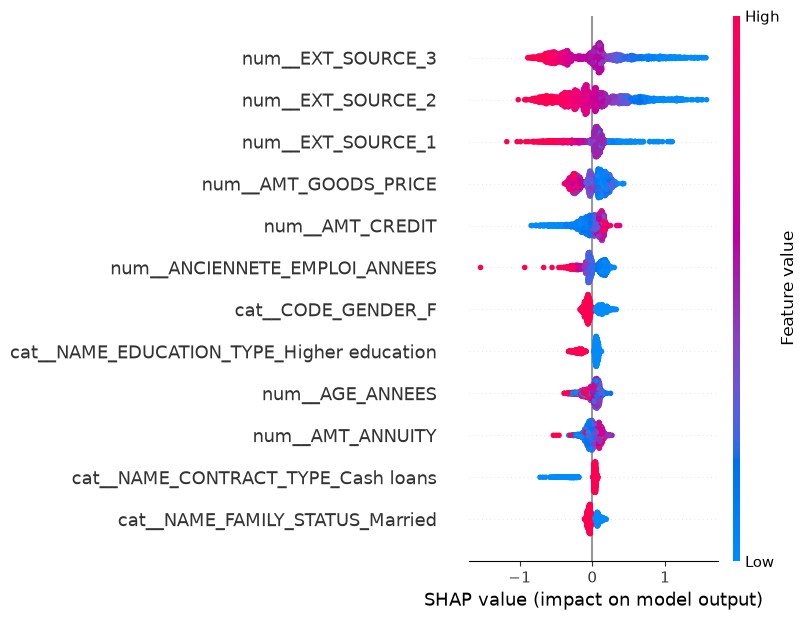

In [21]:
# Graphique detaille SHAP (summary plot)
shap.summary_plot(shap_values, ech, feature_names=noms_features, max_display=12)

### Interprétation détaillée des effets (SHAP summary plot)

Ce second graphique va plus loin : il montre non seulement quelles variables
comptent, mais **dans quel sens** elles agissent. Chaque point représente un
dossier. Sa position horizontale indique l'effet sur la prédiction : à droite,
la variable pousse vers le défaut ; à gauche, vers le remboursement. La
couleur indique la valeur de la variable : rouge pour une valeur élevée, bleu
pour une valeur basse.

La lecture des scores externes de risque est éclairante : leurs points rouges
(scores élevés) se situent à gauche, donc réduisent le risque de défaut, tandis
que les points bleus (scores bas) se trouvent à droite, donc l'augmentent.
Autrement dit, un bon historique de crédit protège du défaut, un mauvais
l'annonce. C'est parfaitement cohérent.

La même logique s'observe pour l'ancienneté d'emploi : les valeurs élevées
(rouge) poussent vers le remboursement. Un emploi stable réduit le risque.
Pour les montants du crédit, les valeurs faibles tendent à être associées à un
risque plus élevé, ce qui s'explique par le fait que les crédits importants
sont souvent accordés à des profils plus solides.

Ce graphique confirme que les décisions du modèle suivent une logique
économique claire et interprétable, condition indispensable à son acceptation
dans un cadre bancaire réglementé.

## 14. Sauvegarde du meilleur modele

On sauvegarde le pipeline complet (preparation + modele) dans un fichier `.pkl`, reutilisable pour l'application.

In [22]:
joblib.dump(pipe_best, "modele_credistore.pkl")
print("Modele sauvegarde dans : modele_credistore.pkl")

# Verification : rechargement
modele_recharge = joblib.load("modele_credistore.pkl")
print("Verification : modele recharge avec succes.")

Modele sauvegarde dans : modele_credistore.pkl
Verification : modele recharge avec succes.


---
**Fin du pipeline.** Le meilleur modele est sauvegarde et pret pour l'integration dans l'application.

Points a retenir pour le memoire :
- Jeu de donnees : 307 511 dossiers, taux de defaut 8,07 % (fort desequilibre).
- Desequilibre traite par ponderation des classes (meilleur que SMOTE ici).
- Le Gradient Boosting obtient la meilleure AUC.
- Les scores externes de risque (proxy de centrale des risques) sont les variables les plus determinantes.